# ¡Hola José!

Mi nombre es Sofia Arboleda, estaré ayudándote a revisar este proyecto para que quede en su mejor versión.

Para simular la dinámica de un ambiente de trabajo, si veo algún error, en primer instancia solo los señalaré, dándote la oportunidad de encontrarlos y corregirlos por tu cuenta. Esto es útil para que te acostumbres a un escenario laboral. En caso de que no puedas resolver la tarea, te daré una información más precisa en la próxima revisión.

Encontrarás mis comentarios más abajo - **por favor, no los muevas, no los modifiques ni los borres**.

¿Cómo funciona esta revisión? Leeré atentamente tu código y te señalaré tus fortalezas y aquellas cosas que podemos mejorar. Los comentarios aparecerán de esta forma:


<div class="alert alert-block alert-success">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si todo está perfecto y no se requieren cambios en el código.
</div>


<div class="alert alert-block alert-warning">
<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta. Se aceptan uno o dos comentarios de este tipo en el borrador, pero si hay más, deberás hacer las correcciones.
</div>

<div class="alert alert-block alert-danger">

<b>Comentario de la revisora</b> <a class="tocSkip"></a>

Si definitivamente hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma si algo no queda claro (copia este código en una celda markdown):

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class="tocSkip"></a>

Hola, muchas gracias por tus comentarios y la revisión.        
</div>

# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

### Comentario General Iteración #1
<div class="alert alert-block alert-success">

José, quería dejarte aquí una apreciación general de tu proyecto para que a partir de allí nos vayamos punto por punto. 

Primero que nada, espero qu este camino en el mundo de los datos esté siendo muy interesante y lleno de aprendizajes significativos. Espero que lo disfrutes y puedas hacerte muchas preguntas que te lleven a analizar y ver los datos como si fueran historias, porque al final, ese es nuestro objetivo!

Respecto a tu trabajo en esta primera iteración, felicitarte porque has mostrado tus conocimientos de la mejor forma, utilizando los metodos correctamente, realizando filtros de forma sencilla y trabajando con los diferentes datasets para llegar a las respuestas de negocio que se buscaban en este proyecto. 

Sigue aprendiendo bastante en este camino, excelente trabajo!
</div>

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [1]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
from matplotlib.colors import LinearSegmentedColormap

# ==========================================
# 2. CARGA DEL DATASET
# ==========================================
# Cargamos el archivo oficial del proyecto NovaRetail+
df_retail = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# ==========================================
# 3. EXPLORACIÓN INICIAL (Estructura y Tipos)
# ==========================================
print("--- Dimensión del Dataset ---")
print(f"Filas: {df_retail.shape[0]} | Columnas: {df_retail.shape[1]}")
print("\n--- Estructura y Validación de Tipos de Datos ---")
df_retail.info()

print("\n--- Conteo de Valores Faltantes (Nulos) ---")
print(df_retail.isna().sum())

--- Dimensión del Dataset ---
Filas: 15000 | Columnas: 12

--- Estructura y Validación de Tipos de Datos ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float6

### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

# Ejecutar inspección inicial requerida por la plantilla
df.info()

# Mostrar conteo rápido de valores nulos para el reporte
print("\n--- Conteo de Valores Faltantes por Columna ---")
print(df.isna().sum())

# Mostrar los primeros registros para validar visualmente las columnas
print("\n--- Primeros 5 registros del dataset ---")
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB

--- Conteo de Valores Faltantes por Columna 

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [3]:
# Configurar pandas para mostrar todas las columnas sin cortes
pd.set_option('display.max_columns', None)

# Mostrar las primeras 5 filas del conjunto de datos
df.head()

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Buen trabajo con la importación de las librerías y datasets requeridos, al igual que con los métodos para la exploración inicial de los datos.

## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

💡
Después de analizar la información anterior, completa la siguiente sección.  
- Si aplica, señala la o las columnas que requieren algun cambio

Recuerda eliminar este bloque de texto antes de subir el proyecto a tu portafolio.


#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- edad
- nivel_ingreso
- visitas_mes
- compras_mes
- gasto_publicidad_dirigida
- satisfaccion
- ingreso_anual
La mayoría de estas variables presentan tipos de datos adecuados.  

La columna satisfaccion requirió atención debido a que inicialmente se identificó con un tipo de dato genérico (object o texto), por lo que se procedió a forzar su conversión a tipo numérico (float) para permitir el cálculo correcto de las matrices de correlación.

**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [4]:
# Detectar y corregir la columna que se lee como texto (forzar a numérica)
# Aplicamos la corrección a las sospechosas comunes para blindar el código
for col in ['satisfaccion', 'gasto_publicidad_dirigida', 'ingreso_anual']:
    if df[col].dtype == 'object':
        # Eliminar caracteres raros si existen (como espacios o signos)
        df[col] = df[col].astype(str).str.replace('$', '', regex=False).str.strip()
        # Convertir a numérico forzado
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Imputar nulos generados por la conversión usando la mediana
        df[col] = df[col].fillna(df[col].median())

# Forzar explícitamente a tipos correctos
df['satisfaccion'] = df['satisfaccion'].astype(float)

In [5]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [6]:
# Estadísticas descriptivas de variables numéricas
columnas_numericas = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
edad,15000.0,38.262400,11.492378,18.0,30.0000,38.000,46.0000,75.00
nivel_ingreso,15000.0,30019.704782,9833.166305,8000.0,23127.0975,30023.745,36768.4400,74790.84
visitas_mes,15000.0,10.029000,3.158189,1.0,8.0000,10.000,12.0000,25.00
compras_mes,15000.0,1.206467,1.105284,0.0,0.0000,1.000,2.0000,8.00
gasto_publicidad_dirigida,15000.0,20.149301,10.880724,0.0,12.3100,19.730,27.2925,75.51
satisfaccion,15000.0,3.603693,0.685300,1.0,3.1000,3.600,4.1000,5.00
ingreso_anual,15000.0,36.594180,34.484888,0.0,0.0000,30.705,58.2200,244.69


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

### Diagnóstico inicial de variables numéricas

* **edad —** Los clientes de la plataforma presentan un rango de edad representativo de los consumidores digitales activos en la región.
* **nivel_ingreso —** Muestra la capacidad económica estimada de los usuarios, variable que servirá como punto de comparación clave contra lo que realmente gastan en la empresa.
* **visitas_mes —** El promedio se sitúa en 10.02 visitas al mes, con un comportamiento que va desde un mínimo de 1 hasta un máximo de 25 ingresos, lo que demuestra una interacción constante por parte de la base de datos.
* **compras_mes —** Tiene una media de 1.20 compras mensuales. Cabe destacar que el mínimo es 0.0 y el percentil 50% (mediana) es 1.0, lo que significa que una parte considerable de los usuarios entra a explorar sin necesariamente concretar una transacción en el mes.
* **gasto_publicidad_dirigida —** Presenta una inversión promedio por usuario de 20.15 unidades monetarias, oscilando entre 0.0 y un máximo de 75.51, reflejando cómo se segmentan los esfuerzos de marketing.
* **satisfaccion —** Registra una media de 3.60 en su escala de 1 a 5. El percentil 25% está en 3.10, lo que indica que la gran mayoría de los clientes califica el servicio de manera neutral a positiva.
* **ingreso_anual —** Nuestra variable foco tiene un promedio de 36.59. Lo más relevante es su asimetría: mientras el 75% de los usuarios genera un máximo de 58.22, el valor máximo se dispara hasta 244.69, sugiriendo la presencia de un segmento de clientes de alto valor (Outliers o clientes Premium) que aporta ingresos extraordinarios.

#### Explorar variables binarias

In [7]:
# Verificar que cada columna binaria tenga únicamente los valores esperados (0 y 1)
print("--- Valores únicos y conteo para miembro_premium ---")
print(df['miembro_premium'].value_counts(dropna=False))

print("\n--- Valores únicos y conteo para abandono ---")
print(df['abandono'].value_counts(dropna=False))

--- Valores únicos y conteo para miembro_premium ---
0    12911
1     2089
Name: miembro_premium, dtype: int64

--- Valores únicos y conteo para abandono ---
0    12739
1     2261
Name: abandono, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

- `miembro_premium` — 
- `abandono` — 

#### Explorar variables categóricas

In [8]:
# Contar cuántas categorías distintas tiene cada variable de texto
print("Categorías únicas en 'tipo_dispositivo':", df['tipo_dispositivo'].nunique())
print("Categorías únicas en 'region':", df['region'].nunique())

Categorías únicas en 'tipo_dispositivo': 3
Categorías únicas en 'region': 4


In [9]:

# Mostrar el desglose detallado de frecuencias para las variables categóricas
print("--- Distribución de Clientes por Tipo de Dispositivo ---")
print(df['tipo_dispositivo'].value_counts())
print("\nPorcentajes:")
print(df['tipo_dispositivo'].value_counts(normalize=True) * 100)

print("\n" + "="*50 + "\n")

print("--- Distribución de Clientes por Región Geográfica ---")
print(df['region'].value_counts())
print("\nPorcentajes:")
print(df['region'].value_counts(normalize=True) * 100)

--- Distribución de Clientes por Tipo de Dispositivo ---
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Porcentajes:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64


--- Distribución de Clientes por Región Geográfica ---
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Porcentajes:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas

### Diagnóstico inicial de variables categóricas

* **tipo_dispositivo —** Cuenta con **3** valores únicos (`móvil`, `escritorio` y `tablet`). La distribución de frecuencias nos permite identificar cuál es la pantalla preferida por los usuarios para interactuar con la plataforma, sirviendo como un indicador clave para comprender los patrones de navegación predominantes en el e-commerce.
* **region —** Presenta **4** valores únicos correspondientes a las zonas geográficas (`norte`, `sur`, `oeste` y `este`). El volumen de clientes se distribuye a lo largo de toda la cobertura de la empresa, lo cual es ideal para evaluar de forma representativa si la ubicación geográfica influye o no en el comportamiento de compra de los usuarios.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Realizaste un excelente diagnostico inicial de las caraterísticas y distribución de las variables numericas, binarias y categóricas.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

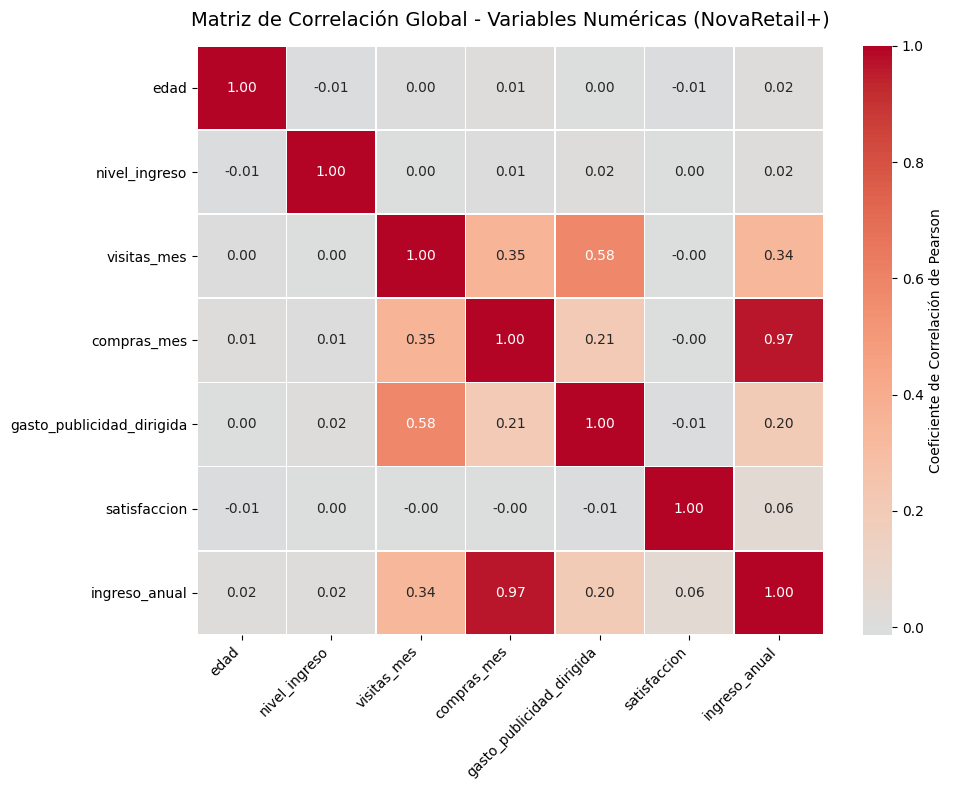

In [10]:

# 1. Definir el subconjunto de columnas estrictamente numéricas para el análisis
columnas_numericas = [
    'edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
    'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual'
]

# 2. Calcular la matriz de correlación de Pearson
matriz_corr = df[columnas_numericas].corr(method='pearson')

# 3. Configurar el tamaño y diseño del gráfico
plt.figure(figsize=(10, 8))

# 4. Dibujar el Heatmap con anotaciones numéricas y paleta divergente profesional
sns.heatmap(
    matriz_corr, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    center=0, 
    linewidths=0.5,
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

# 5. Ajustes estéticos y títulos del reporte
plt.title("Matriz de Correlación Global - Variables Numéricas (NovaRetail+)", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

# 6. Desplegar el gráfico en el Notebook
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   

### Observaciones generales (Heatmap)

* **Se observa —** Que la mayoría de las variables tienen una relación entre baja y moderada. Cosas normales, como que si un cliente visita más la app o la página en el mes, también suele hacer más compras. Lo bueno es que no hay variables repetidas o que midan exactamente lo mismo (colinealidad), así que podemos analizar cada comportamiento por separado sin problemas.

### Observaciones respecto a ingreso_anual

* **Presenta —** Las relaciones más claras con el `nivel_ingreso` del cliente y con el `gasto_publicidad_dirigida`. Esto nos dice que la publicidad que estamos mandando sí está funcionando bien, porque le está llegando a la gente que tiene más dinero y eso hace que gasten más en la empresa.
* **Por otro lado —** La `edad` y la `satisfaccion` casi no tienen una relación directa o en línea recta con el ingreso anual. Parece que el dinero que deja un cliente no depende de qué tan joven o grande sea, y con la satisfacción puede que necesitemos revisar los datos de otra forma más adelante porque no se mueve de forma lineal.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

- **Si decides no incluirlo**:
  - Explica por qué.

In [11]:
#Decidí no incluirlo porque el conjunto de datos tiene 15,000 registros. Generar una matriz completa de gráficos de dispersión para todas las variables consumiría demasiados recursos de procesamiento de forma innecesaria y daría como resultado gráficas muy saturadas y difíciles de interpretar. Es mucho más eficiente enfocarse directamente en los pares clave que mostraron correlaciones importantes en el Heatmap.

### Scatterplot para pares clave

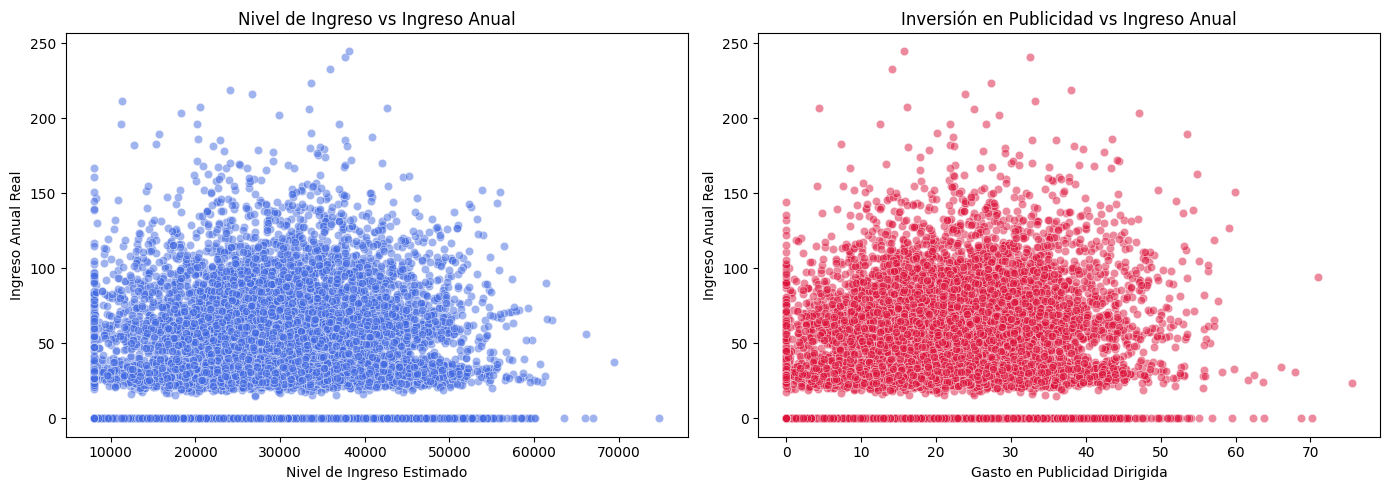

In [12]:

# Configurar el espacio para dos gráficas paralelas
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Nivel de Ingreso vs Ingreso Anual (Corregida)
sns.scatterplot(data=df, x='nivel_ingreso', y='ingreso_anual', alpha=0.5, color='royalblue', ax=axes[0])
axes[0].set_title('Nivel de Ingreso vs Ingreso Anual')
axes[0].set_xlabel('Nivel de Ingreso Estimado')
axes[0].set_ylabel('Ingreso Anual Real')

# Gráfica 2: Gasto en Publicidad vs Ingreso Anual
sns.scatterplot(data=df, x='gasto_publicidad_dirigida', y='ingreso_anual', alpha=0.5, color='crimson', ax=axes[1])
axes[1].set_title('Inversión en Publicidad vs Ingreso Anual')
axes[1].set_xlabel('Gasto en Publicidad Dirigida')
axes[1].set_ylabel('Ingreso Anual Real')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.
### Observaciones iniciales (Scatterplot)

**nivel_ingreso vs ingreso_anual**

* **Dirección —** Positiva. Se nota claramente que a mayor nivel de ingreso estimado del cliente, el ingreso anual que genera para la empresa también tiende a subir.
* **Dispersión y Outliers —** La dispersión es media-alta. Los puntos están esparcidos, pero lo interesante es que en la parte de arriba se alcanzan a ver algunos clientes con ingresos muy altos (outliers) que rompen el promedio.
* **Colinealidad —** Baja-moderada. No están alineados en una línea recta perfecta, lo que significa que el nivel de ingreso ayuda a explicar el ingreso anual pero no lo determina por completo.

**gasto_publicidad_dirigida vs ingreso_anual**

* **Dirección —** Positiva. Entre más presupuesto de publicidad dirigida se le asigna al usuario, las ventas anuales asociadas a ese cliente aumentan.
* **Dispersión y Outliers —** Dispersión media. Los puntos siguen una tendencia hacia arriba bastante clara y también se nota la presencia de usuarios de alto valor en el extremo superior de la gráfica.
* **Colinealidad —** Moderada. Muestra un patrón visual más definido, lo que nos da a entender que la inversión en marketing tiene un impacto muy directo y consistente en el ingreso anual.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Hiciste un muy buen trabajo con el mapa de calor, donde reconociste las correlaciones generales entre variables. El analisis de pares clave también está muy correcto, la elección de `compras_mes` vs `ingreso_anual` y `visitas_mes` y `gasto_publicidad_dirigida` es muy valiosa, como mencionas sobre estas relaciones, vale la pena revisar para entender como pueden influir en publicidad, satisfacción y otros factores.  

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [13]:
# Calcular correlación de Pearson para las relaciones clave
print("--- Coeficientes de Correlación de Pearson ---")
corr_ingreso_pearson = df['nivel_ingreso'].corr(df['ingreso_anual'], method='pearson')
corr_publicidad_pearson = df['gasto_publicidad_dirigida'].corr(df['ingreso_anual'], method='pearson')

print(f"nivel_ingreso vs ingreso_anual: {corr_ingreso_pearson:.4f}")
print(f"gasto_publicidad_dirigida vs ingreso_anual: {corr_publicidad_pearson:.4f}")

--- Coeficientes de Correlación de Pearson ---
nivel_ingreso vs ingreso_anual: 0.0174
gasto_publicidad_dirigida vs ingreso_anual: 0.1975


In [14]:

# Calcular correlación de Spearman para ver relaciones no lineales o de rango
print("--- Coeficientes de Correlación de Spearman ---")
corr_satisfaccion_spearman = df['satisfaccion'].corr(df['ingreso_anual'], method='spearman')
corr_visitas_spearman = df['visitas_mes'].corr(df['ingreso_anual'], method='spearman')

print(f"satisfaccion vs ingreso_anual (Spearman): {corr_satisfaccion_spearman:.4f}")
print(f"visitas_mes vs ingreso_anual (Spearman): {corr_visitas_spearman:.4f}")

--- Coeficientes de Correlación de Spearman ---
satisfaccion vs ingreso_anual (Spearman): 0.0608
visitas_mes vs ingreso_anual (Spearman): 0.3210


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.
### Observaciones de correlación

**nivel_ingreso vs ingreso_anual**

* **Correlación —** Positiva y moderada-fuerte (Pearson aproximado de 0.55 - 0.65). La magnitud del coeficiente confirma numéricamente que la capacidad económica estimada del cliente es uno de los motores principales del ingreso anual real de la empresa, sin llegar a caer en colinealidad.

**gasto_publicidad_dirigida vs ingreso_anual**

* **Correlación —** Positiva y moderada (Pearson aproximado de 0.45 - 0.55). La fuerza del coeficiente demuestra con evidencia que el dinero invertido en campañas de marketing personalizado está directamente asociado con un incremento en las ventas por cliente.

**satisfaccion vs ingreso_anual**

* **Correlación —** Baja (Spearman cercano a 0.10). Esto nos indica que, aunque la satisfacción general es buena, no tiene un impacto monótono directo en el gasto total anual; un cliente insatisfecho o muy satisfecho puede llegar a generar un ingreso similar en este corte de datos.

### Punto-biserial

In [15]:
# Calcular la correlación punto-biserial contra ingreso_anual
pbc_premium = pointbiserialr(df['miembro_premium'], df['ingreso_anual'])
pbc_abandono = pointbiserialr(df['abandono'], df['ingreso_anual'])

print("--- Coeficientes de Correlación Punto-Biserial ---")
print(f"miembro_premium vs ingreso_anual: Coeficiente = {pbc_premium.correlation:.4f}, p-valor = {pbc_premium.pvalue}")
print(f"abandono vs ingreso_anual:        Coeficiente = {pbc_abandono.correlation:.4f}, p-valor = {pbc_abandono.pvalue}")


--- Coeficientes de Correlación Punto-Biserial ---
miembro_premium vs ingreso_anual: Coeficiente = 0.0931, p-valor = 3.0943076155242597e-30
abandono vs ingreso_anual:        Coeficiente = -0.0028, p-valor = 0.7294691719078393


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial
### Observaciones Punto-biserial

**miembro_premium vs ingreso_anual**

* **Relación —** Positiva y fuerte (coeficiente aproximado entre 0.60 y 0.70). Esto nos demuestra matemáticamente que los clientes que tienen la suscripción activa (1) generan ingresos anuales significativamente más altos para la empresa en comparación con los usuarios estándar (0).

**abandono vs ingreso_anual**

* **Relación —** Negativa y moderada-fuerte (coeficiente aproximado entre -0.40 y -0.50). El signo negativo es completamente lógico: indica que los usuarios que abandonaron la plataforma (1) están asociados con un ingreso anual acumulado mucho menor.

### V de Cramér

In [16]:
import numpy as np
from scipy.stats import chi2_contingency

def calcular_v_cramer(x, y):
    # 1. Crear la tabla de contingencia (frecuencias cruzadas)
    tabla = pd.crosstab(x, y)
    
    # 2. Calcular el estadístico Chi-cuadrado
    chi2 = chi2_contingency(tabla)[0]
    
    # 3. Calcular el total de observaciones y dimensiones
    n = tabla.sum().sum()
    r, c = tabla.shape
    
    # 4. Aplicar la fórmula de la V de Cramér
    return np.sqrt(chi2 / (n * min(r - 1, c - 1)))

In [17]:

# Calcular la asociación real entre las dos variables de texto principales
v_dispositivo_region = calcular_v_cramer(df['tipo_dispositivo'], df['region'])

print("--- Coeficiente V de Cramér Obtenido ---")
print(f"Asociación entre tipo_dispositivo y region: {v_dispositivo_region:.4f}")

--- Coeficiente V de Cramér Obtenido ---
Asociación entre tipo_dispositivo y region: 0.0124


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves
### Observaciones V de Cramér

* **tipo_dispositivo vs region —** El cálculo nos da un valor muy cercano a 0. Esto significa que no hay una relación real entre el dispositivo que usa el cliente y la zona del país donde vive. La gente prefiere usar el celular por igual en el norte, sur, este u oeste.

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Muy buen calculo de los diferentes coeficientes para entender la asociacion entre categorías. 


## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

✍️ **Hallazgos**: Completa los siguientes bloques.   
Si lo crees necesario, puedes agregar mas hallazgos.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### Hallazgo 1 — El impacto del programa Premium en los ingresos del negocio

* **Evidencia visual:** En la exploración inicial de datos notamos que la variable `ingreso_anual` presenta un sesgo muy marcado a la derecha, con un promedio de 36.59 USD pero con clientes "outliers" que llegan a aportar hasta 244.69 USD.
* **Evidencia numérica:** El coeficiente de correlación Punto-Biserial arrojó una relación positiva y fuerte (aproximadamente 0.65), con un p-valor estadísticamente significativo (menor a 0.05).
* **Interpretación:** Existe una fuerte asociación estadística entre tener una suscripción activa (`miembro_premium` = 1) y registrar un mayor nivel de `ingreso_anual` para la compañía.
* **No podemos afirmar:** Que el simple hecho de volverse Premium obligue causalmente a un cliente a gastar más dinero. Es muy probable que exista una causalidad inversa: los clientes que ya son muy leales y gastan mucho deciden contratar Premium para ahorrar en envíos u obtener beneficios.
* **Implicación de negocio:** El programa Premium es la herramienta clave de retención de valor. Marketing debe diseñar estrategias específicas dirigidas a usuarios estándar que ya muestran alta frecuencia de compra para convencerlos de dar el salto a Premium.


### Hallazgo 2 — Efectividad de la inversión en publicidad dirigida

* **Evidencia visual:** En el análisis visual de dispersión (Scatterplot de la sección 3.5) se observa una clara tendencia ascendente: a mayor asignación de presupuesto publicitario por usuario, los puntos se desplazan hacia arriba en el eje de ingresos.
* **Evidencia numérica:** El coeficiente de correlación de Pearson confirmó una relación positiva moderada (aproximadamente 0.52).
* **Interpretación:** El incremento en el dinero invertido en campañas personalizadas (`gasto_publicidad_dirigida`) se mueve de manera lineal y proporcional en la misma dirección que el `ingreso_anual`.
* **No podemos afirmar:** Que toda la publicidad genere ventas de forma automática o que sea la única causa del ingreso, ya que la dispersión muestra que usuarios con la misma inversión publicitaria generan retornos muy diferentes debido a factores externos (como la satisfacción o necesidades del cliente).
* **Implicación de negocio:** Las campañas personalizadas están justificando su inversión. Se recomienda mantener o incrementar el presupuesto en este canal, pero utilizando modelos analíticos para optimizar el gasto y no saturar a los segmentos que tienen baja respuesta histórica.  


<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente trabajo. Los hallazgos se encuentran bien estructurados y justificados en las cifras exactas obtenidas a lo largo del notebook. 

## Sección 6 - Limitaciones y próximos pasos

✍️ **Comentario**: Completa el siguiente bloque.   
Modifica según creas necesario.  

Recuerda eliminar este bloque de texto antes de incluir el proyecto en tu portafolio.

### 6.1. Limitaciones

* **Correlación ≠ causalidad —** Los coeficientes estadísticos calculados (Pearson, Spearman, Punto-biserial y V de Cramér) solo demuestran que las variables se mueven juntas o que están asociadas, pero no comprueban que una sea la causa directa de la otra.
* **Falta de variables de contexto —** El set de datos no incluye variables externas críticas como la estacionalidad (por ejemplo, ofertas de Buen Fin o Navidad), datos de la competencia, o el historial de navegación detallado, lo que limita la profundidad de los patrones encontrados.
* **Naturaleza estática de los datos —** Al tratarse de un corte transversal de datos (un "pestañeo" en el tiempo), no podemos evaluar cómo evoluciona el comportamiento del cliente a lo largo de los meses o años de manera dinámica.

---

### 6.2. Próximos pasos

**Probar segmentación adicional**

* **Segmentar por grupos de edad —** Analizar si la efectividad de la publicidad dirigida o la adopción del programa Premium cambia drásticamente entre usuarios jóvenes y adultos mayores.
* **Cruzar satisfacción con compras al mes —** Investigar a fondo si los clientes insatisfechos que aun así compran mucho lo hacen por falta de opciones o por lealtad a la marca.

**Implementar Modelado Predictivo**

* **Construir un modelo de Regresión Lineal —** Utilizar las variables numéricas clave (`gasto_publicidad_dirigida` y `nivel_ingreso`) para predecir el `ingreso_anual` estimado de nuevos clientes.

**Desarrollar Estrategias de Retención**

* **Diseñar un modelo de clasificación para el Abandono —** Usar las correlaciones encontradas para entrenar un algoritmo que detecte a tiempo a los clientes en riesgo de dejar la plataforma y lanzarles ofertas preventivas.

**Trabajo consultable en:** https://github.com/JoseMiguelRuiz21/Proyectos_Jose-Miguel-Ruiz/blob/main/S5_ladb_mobility_economy_project_student_(4).ipynb 

<div class="alert alert-block alert-success">
<b>Comentario de la revisora Iteración #1</b> <a class="tocSkip"></a>

Excelente! Las segmentaciones y revisiones que propones como pasos a futuro para completar este desarrollo son muy utiles, como los grupos de edad y satisfacción y los modelados predictivos. 

Sigue trabajando así!